In [73]:
import os
import sys
import pandas as pd

# 2016 census data - https://docs.safegraph.com/docs/open-census-data
HOUSING_PATH = "datasets/housing/"

df = pd.read_csv(os.path.join(HOUSING_PATH, 'cbg_b19.csv'))
df.head()

,census_block_group,B19001e1,B19001m1,B19001e2,B19001m2,B19001e3,B19001m3,B19001e4,B19001m4,B19001e5,...,B19313Ee1,B19313Em1,B19313Fe1,B19313Fm1,B19313Ge1,B19313Gm1,B19313He1,B19313Hm1,B19313Ie1,B19313Im1
0,10010201001,284,53,24,29,33,25,23,22,25,...,NaN,NaN,NaN,NaN,NaN,NaN,13071500.0,4351307.0,NaN,NaN
1,10010201002,456,64,8,10,15,24,14,22,5,...,NaN,NaN,NaN,NaN,932100.0,777912.0,35555700.0,10801102.0,NaN,NaN
2,10010202001,386,78,47,39,108,47,37,31,0,...,NaN,NaN,NaN,NaN,NaN,NaN,5889300.0,3270956.0,NaN,NaN
3,10010202002,452,85,32,27,37,30,15,15,18,...,NaN,NaN,NaN,NaN,23600.0,30808.0,17240700.0,4375298.0,NaN,NaN
4,10010203001,824,108,23,24,34,50,16,18,17,...,NaN,NaN,3641300.0,4736228.0,996500.0,1403150.0,35733400.0,6545810.0,3641300.0,4736228.0


In [74]:
print(df.census_block_group.astype(str).str.startswith('6').value_counts())

False    197121
True      23212
Name: census_block_group, dtype: int64


The above should read 23212 true because California has 8,057 census tracts, 23,212 block groups, and 710,145 blocks.

In [75]:
df = df[df.census_block_group.astype(str).str.startswith('6')]
df.head()

,census_block_group,B19001e1,B19001m1,B19001e2,B19001m2,B19001e3,B19001m3,B19001e4,B19001m4,B19001e5,...,B19313Ee1,B19313Em1,B19313Fe1,B19313Fm1,B19313Ge1,B19313Gm1,B19313He1,B19313Hm1,B19313Ie1,B19313Im1
10297,60014001001,1292,54,26,23,9,16,0,12,27,...,NaN,NaN,4381300.0,5538020.0,8584700.0,7328361.0,255360900.0,42315354.0,4415200.0,3319891.0
10298,60014002001,443,38,0,12,0,12,5,8,0,...,NaN,NaN,880500.0,893056.0,3209600.0,2713255.0,79994300.0,13114264.0,7178200.0,3026027.0
10299,60014002002,370,42,9,10,4,6,6,9,0,...,NaN,NaN,NaN,NaN,2045900.0,1802089.0,50266200.0,9945314.0,2073800.0,1358482.0
10300,60014003001,483,102,13,21,9,15,0,12,0,...,NaN,NaN,NaN,NaN,2131700.0,2882033.0,121226100.0,75554117.0,4789200.0,4342862.0
10301,60014003002,717,135,28,33,21,32,48,46,0,...,NaN,NaN,NaN,NaN,3945300.0,4707528.0,53906800.0,15097789.0,7062200.0,5385127.0


In [76]:
keep_col = ['census_block_group','B19001e1','B19001e2','B19001e3',
            'B19001e4', 'B19001e5','B19001e6', 'B19001e7',
            'B19001e8', 'B19001e9','B19001e10', 'B19001e11',
            'B19001e12', 'B19001e13','B19001e14', 'B19001e15',
            'B19001e16', 'B19001e17']
household_income_df = df[keep_col]
household_income_df.head()

,census_block_group,B19001e1,B19001e2,B19001e3,B19001e4,B19001e5,B19001e6,B19001e7,B19001e8,B19001e9,B19001e10,B19001e11,B19001e12,B19001e13,B19001e14,B19001e15,B19001e16,B19001e17
10297,60014001001,1292,26,9,0,27,52,46,9,0,9,34,23,141,77,113,109,617
10298,60014002001,443,0,0,5,0,0,0,16,0,0,22,20,32,65,42,47,194
10299,60014002002,370,9,4,6,0,0,11,0,11,6,17,36,13,48,42,67,100
10300,60014003001,483,13,9,0,0,0,0,14,19,0,0,31,41,38,52,54,212
10301,60014003002,717,28,21,48,0,27,0,28,89,0,92,0,166,0,95,30,93


In [77]:
household_income_df = household_income_df.rename({'B19001e1': 'Total',
                                                  'B19001e2': '<10k',
                                                  'B19001e3': '10k to $14,999',
                                                  'B19001e4': '15k to $19,999',
                                                  'B19001e5': '20k to $24,999',
                                                  'B19001e6': '25k to $29,999',
                                                  'B19001e7': '30k to $34,999',
                                                  'B19001e8': '35k to $39,999',
                                                  'B19001e9': '40k to $44,999',
                                                  'B19001e10': '45k to $49,999',
                                                  'B19001e11': '50k to $59,999',
                                                  'B19001e12': '60k to $74,999',
                                                  'B19001e13': '75k to $99,999',
                                                  'B19001e14': '100k to $124,999',
                                                  'B19001e15': '125k to $149,999',
                                                  'B19001e16': '150k to $199,999',
                                                  'B19001e17': '200k+'}, axis=1)
household_income_df = household_income_df.reset_index(drop=True)
household_income_df.head()

,census_block_group,Total,<10k,"10k to $14,999","15k to $19,999","20k to $24,999","25k to $29,999","30k to $34,999","35k to $39,999","40k to $44,999","45k to $49,999","50k to $59,999","60k to $74,999","75k to $99,999","100k to $124,999","125k to $149,999","150k to $199,999",200k+
0,60014001001,1292,26,9,0,27,52,46,9,0,9,34,23,141,77,113,109,617
1,60014002001,443,0,0,5,0,0,0,16,0,0,22,20,32,65,42,47,194
2,60014002002,370,9,4,6,0,0,11,0,11,6,17,36,13,48,42,67,100
3,60014003001,483,13,9,0,0,0,0,14,19,0,0,31,41,38,52,54,212
4,60014003002,717,28,21,48,0,27,0,28,89,0,92,0,166,0,95,30,93


In [78]:
new_result = []

for i, row in household_income_df.iterrows():
    left_idx = 2
    right_idx = 17
    left_remaining = row[left_idx]
    right_remaining = row[right_idx]
    
    while left_idx < right_idx:
        if left_remaining > right_remaining:
            left_remaining -= right_remaining
            right_idx -= 1
            right_remaining = row[right_idx]
        else:
            right_remaining -= left_remaining
            left_idx += 1
            left_remaining = row[left_idx]

    # represent each data point as a categorical number (-1 is because we start at 2)
    new_result.append([row[0], left_idx - 1])
    
income_df = pd.DataFrame(new_result, columns = ['census_block_group', 'Median Household Income'])
income_df.head()

,census_block_group,Median Household Income
0,60014001001,15
1,60014002001,15
2,60014002002,14
3,60014003001,15
4,60014003002,12


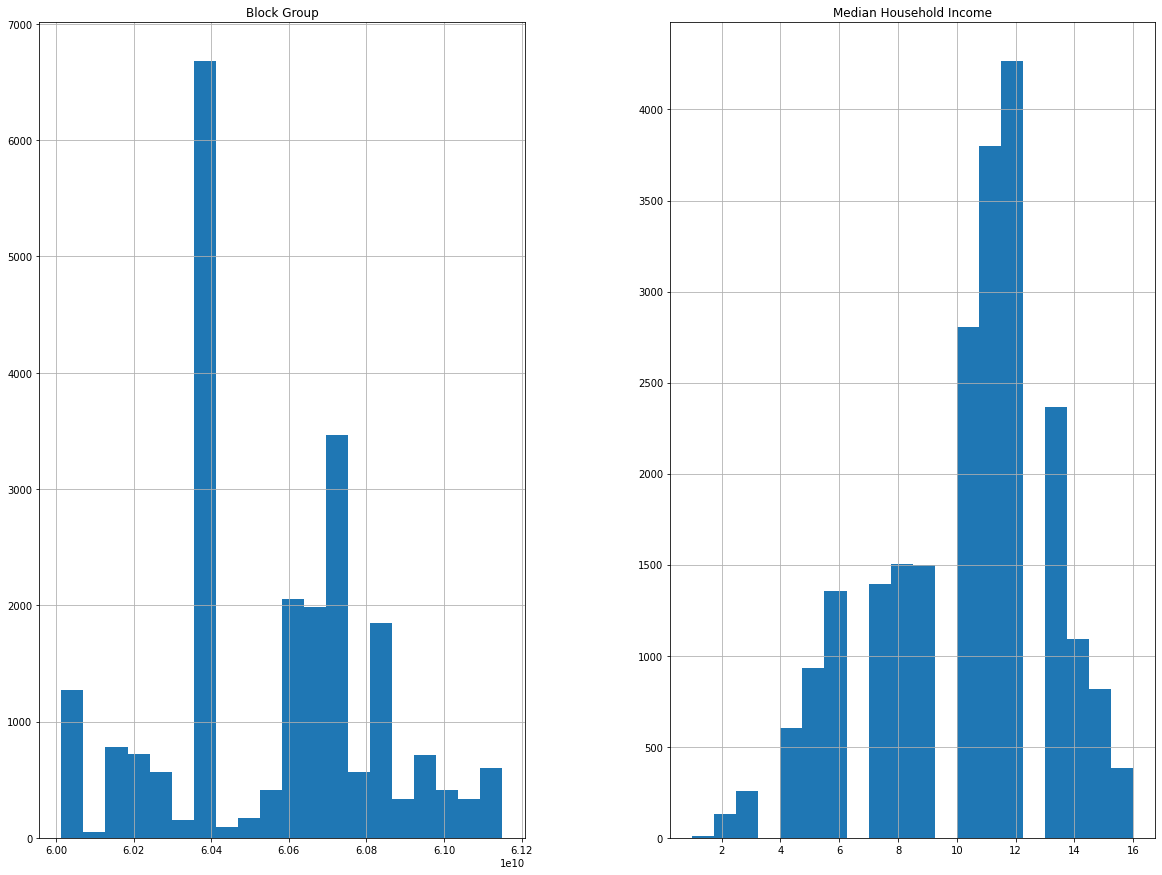

In [79]:
import matplotlib.pyplot as plt

income_data.hist(bins=20, figsize=(20,15))
plt.show()

In [80]:
# 2016 census data - https://docs.safegraph.com/docs/open-census-data
HOUSING_PATH = "datasets/housing/"

df = pd.read_csv(os.path.join(HOUSING_PATH, 'cbg_b25.csv'))
print(df.census_block_group.astype(str).str.startswith('6').value_counts())
df = df[df.census_block_group.astype(str).str.startswith('6')]
df.head()

False    197121
True      23212
Name: census_block_group, dtype: int64


,census_block_group,B25001e1,B25001m1,B25002e1,B25002m1,B25002e2,B25002m2,B25002e3,B25002m3,B25003e1,...,B25093e25,B25093m25,B25093e26,B25093m26,B25093e27,B25093m27,B25093e28,B25093m28,B25093e29,B25093m29
10297,60014001001,1349,26,1349,26,1292,54,57,48,1292,...,33,30,26,20,18,20,97,41,7,11
10298,60014002001,449,36,449,36,443,38,6,9,443,...,25,16,17,15,5,8,0,12,0,12
10299,60014002002,396,39,396,39,370,42,26,25,370,...,11,11,0,12,9,10,11,12,9,10
10300,60014003001,517,105,517,105,483,102,34,50,483,...,0,12,0,12,0,12,22,35,0,12
10301,60014003002,717,135,717,135,717,135,0,12,717,...,65,100,20,34,0,12,0,12,0,12


In [90]:
keep_col = ['census_block_group','B25008e1', 'B25018e1',
            'B25035e1', 'B25041e2', 'B25041e3',
            'B25041e4', 'B25041e5', 'B25041e6',
            'B25041e7', 'B25077e1', 'C15010e1',
            'C15010e2', 'C15010e3', 'C15010e4',
            'C15010e5', 'C15010e6'] # remove C's to make it work
housing_df = df[keep_col]
housing_df.head()

,census_block_group,B25008e1,B25018e1,B25035e1,B25041e2,B25041e3,B25041e4,B25041e5,B25041e6,B25041e7,B25077e1
10297,60014001001,3018,6.9,1992.0,0,89,181,535,395,149,1074100.0
10298,60014002001,1105,6.6,1939.0,6,43,81,182,108,29,1022900.0
10299,60014002002,764,5.7,1939.0,25,100,78,123,42,28,875000.0
10300,60014003001,1466,6.3,1939.0,0,98,98,142,25,154,1316400.0
10301,60014003002,1229,4.7,1939.0,104,196,192,192,33,0,828200.0


In [82]:
housing_df = housing_df.rename({'B25008e1': 'Population',
                                  'B25018e1': 'Medium Number of Rooms',
                                  'B25035e1': 'Median Housing Age',
                                  'B25041e2': 'Housing units with 0 bedrooms',
                                  'B25041e3': 'Housing units with 1 bedroom',
                                  'B25041e4': 'Housing units with 2 bedrooms',
                                  'B25041e5': 'Housing units with 3 bedrooms',
                                  'B25041e6': 'Housing units with 4 bedrooms',
                                  'B25041e7': 'Housing units with 5+ bedrooms',
                                  'B25077e1': 'Median Value: Owner-occupied housing units',
                                  'C15010e1': "Total Bachelor's degress in population over 25",
                                  'C15010e2': 'Science and Engineering',
                                  'C15010e3': 'Science and Engineering Related Fields',
                                  'C15010e4': 'Business',
                                  'C15010e5': 'Education',
                                  'C15010e6': 'Arts & Humanities and Other'}, axis=1)
housing_df = housing_df.reset_index(drop=True)
housing_df.head()

,census_block_group,Population,Medium Number of Rooms,Median Housing Age,Housing units with 0 bedrooms,Housing units with 1 bedroom,Housing units with 2 bedrooms,Housing units with 3 bedrooms,Housing units with 4 bedrooms,Housing units with 5+ bedrooms,Median Value: Owner-occupied housing units
0,60014001001,3018,6.9,1992.0,0,89,181,535,395,149,1074100.0
1,60014002001,1105,6.6,1939.0,6,43,81,182,108,29,1022900.0
2,60014002002,764,5.7,1939.0,25,100,78,123,42,28,875000.0
3,60014003001,1466,6.3,1939.0,0,98,98,142,25,154,1316400.0
4,60014003002,1229,4.7,1939.0,104,196,192,192,33,0,828200.0


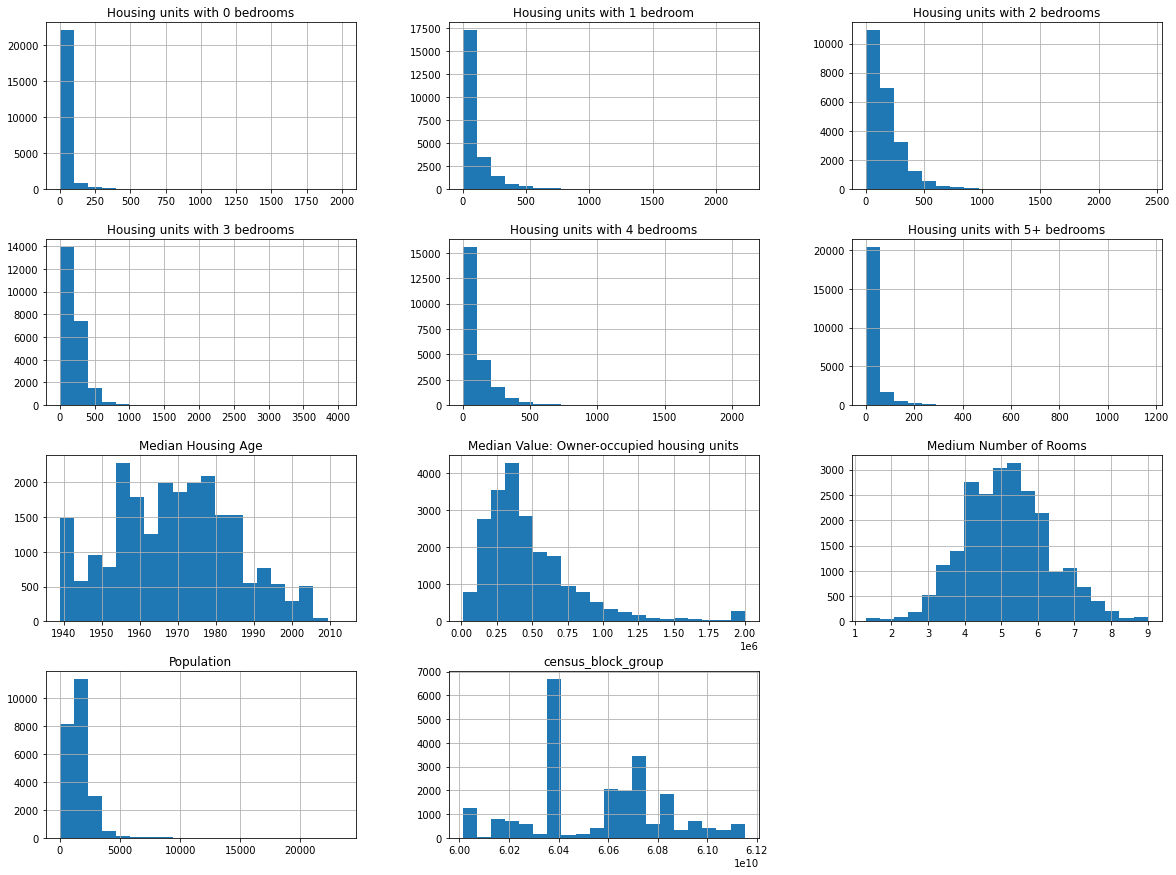

In [83]:
housing_df.hist(bins=20, figsize=(20,15))
plt.show()

In [84]:
final_data = pd.merge(income_df, housing_df, on='census_block_group', how='outer')
print(final_data.shape)
final_data.head()

(23212, 12)


,census_block_group,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Housing units with 0 bedrooms,Housing units with 1 bedroom,Housing units with 2 bedrooms,Housing units with 3 bedrooms,Housing units with 4 bedrooms,Housing units with 5+ bedrooms,Median Value: Owner-occupied housing units
0,60014001001,15,3018,6.9,1992.0,0,89,181,535,395,149,1074100.0
1,60014002001,15,1105,6.6,1939.0,6,43,81,182,108,29,1022900.0
2,60014002002,14,764,5.7,1939.0,25,100,78,123,42,28,875000.0
3,60014003001,15,1466,6.3,1939.0,0,98,98,142,25,154,1316400.0
4,60014003002,12,1229,4.7,1939.0,104,196,192,192,33,0,828200.0


In [85]:
final_data.corr()

,census_block_group,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Housing units with 0 bedrooms,Housing units with 1 bedroom,Housing units with 2 bedrooms,Housing units with 3 bedrooms,Housing units with 4 bedrooms,Housing units with 5+ bedrooms,Median Value: Owner-occupied housing units
census_block_group,1.000000,0.073958,0.050146,0.089166,0.200964,-0.042547,-0.046867,0.009737,0.082177,0.089983,0.049038,0.029338
Median Household Income,0.073958,1.000000,0.022435,0.611271,0.091862,-0.212330,-0.249625,-0.239445,0.170970,0.377943,0.309936,0.597141
Population,0.050146,0.022435,1.000000,0.068274,0.366348,0.091657,0.206130,0.359808,0.611837,0.635256,0.526772,-0.112749
Medium Number of Rooms,0.089166,0.611271,0.068274,1.000000,0.206738,-0.448101,-0.617304,-0.472581,0.313694,0.580661,0.463811,0.292617
Median Housing Age,0.200964,0.091862,0.366348,0.206738,1.000000,-0.076894,-0.006675,0.117642,0.333212,0.421449,0.302255,-0.194031
Housing units with 0 bedrooms,-0.042547,-0.212330,0.091657,-0.448101,-0.076894,1.000000,0.488390,0.183738,-0.149268,-0.141079,-0.070753,0.034894
Housing units with 1 bedroom,-0.046867,-0.249625,0.206130,-0.617304,-0.006675,0.488390,1.000000,0.521995,-0.184258,-0.229143,-0.123518,0.027522
Housing units with 2 bedrooms,0.009737,-0.239445,0.359808,-0.472581,0.117642,0.183738,0.521995,1.000000,0.080422,-0.171832,-0.108168,-0.114889
Housing units with 3 bedrooms,0.082177,0.170970,0.611837,0.313694,0.333212,-0.149268,-0.184258,0.080422,1.000000,0.488877,0.264665,-0.129970
Housing units with 4 bedrooms,0.089983,0.377943,0.635256,0.580661,0.421449,-0.141079,-0.229143,-0.171832,0.488877,1.000000,0.679223,0.131029


In [86]:
new_result = []

for i, row in final_data.iterrows():
    left_idx = 5
    right_idx = 10
    left_remaining = row[left_idx]
    right_remaining = row[right_idx]
    
    while left_idx < right_idx:
        if left_remaining > right_remaining:
            left_remaining -= right_remaining
            right_idx -= 1
            right_remaining = row[right_idx]
        else:
            right_remaining -= left_remaining
            left_idx += 1
            left_remaining = row[left_idx]

    # represent each data point as a categorical number (-5 is because we start at 5)
    new_result.append([row[0], left_idx - 5])
    
median_num_bedrooms = pd.DataFrame(new_result, columns = ['census_block_group', 'Median Household Bedrooms'])
median_num_bedrooms.head()

,census_block_group,Median Household Bedrooms
0,6.001400e+10,3
1,6.001400e+10,3
2,6.001400e+10,2
3,6.001400e+10,3
4,6.001400e+10,2


In [87]:
final_data = pd.merge(final_data, median_num_bedrooms, on='census_block_group', how='outer')
print(final_data.shape)
final_data = final_data.drop(['Housing units with 0 bedrooms',
                              'Housing units with 1 bedroom',
                              'Housing units with 2 bedrooms',
                              'Housing units with 3 bedrooms',
                              'Housing units with 4 bedrooms',
                              'Housing units with 5+ bedrooms'], axis=1)
final_data.head()

(23212, 13)


,census_block_group,Median Household Income,Population,Medium Number of Rooms,Median Housing Age,Median Value: Owner-occupied housing units,Median Household Bedrooms
0,60014001001,15,3018,6.9,1992.0,1074100.0,3
1,60014002001,15,1105,6.6,1939.0,1022900.0,3
2,60014002002,14,764,5.7,1939.0,875000.0,2
3,60014003001,15,1466,6.3,1939.0,1316400.0,3
4,60014003002,12,1229,4.7,1939.0,828200.0,2


In [88]:
final_data.to_csv(os.path.join(HOUSING_PATH, 'housing-census-data-preprocessed.csv'), index=False)